# 05 -- Optimization

Run the full optimization loop with **real CG** and **elevon trim** constraints:
1. Load trained 10-target surrogate (with Cl_beta, CLd01, Cmd01)
2. Configure mission + constraints (aero + propulsion + **trimmability**)
3. Surrogate-assisted Differential Evolution (with CG correction in reconstruct)
4. AVL validation of top candidates (with elevon trim)
5. Best feasible design with control authority check

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from src.config import load_all
from src.surrogate.model import SurrogateModel
from src.optimization.problem import run_surrogate_assisted, run_differential_evolution
from src.optimization.database import EvaluationDatabase
from src.parameterization.design_variables import params_from_vector

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

from src.visualization.style import apply_style, COLORS
apply_style()

In [2]:
%load_ext autoreload
%autoreload 2

## 1. Configuration

In [3]:
cfg = load_all()
mission = cfg['mission']
feasibility = cfg['feasibility']

print(f'Mission: V={mission.velocity} m/s, MTOW={mission.mtow} kg')
print(f'Mass budget: {mission.mass_budget:.3f} kg')
print(f'T_available @ cruise: {mission.thrust_available:.2f} N')
print()
print(f'v2 constraints:')
print(f'  SM range:            [{feasibility.sm_min:.0%}, {feasibility.sm_max:.0%}] MAC')
print(f'  Elevon defl max:     {feasibility.elevon_deflection_max:.0f} deg')
print(f'  Cl_beta/Cn_beta max: {feasibility.cl_beta_cn_beta_max:.0f}')
print(f'  T/D min:             {feasibility.td_min:.1f}')
print(f'  Endurance min:       {feasibility.endurance_min:.0f} s ({feasibility.endurance_min/60:.0f} min)')
print(f'  Vs max:              {feasibility.vs_max:.0f} m/s')
print(f'  Drag margin:         {feasibility.drag_margin:.2f}')

Mission: V=25.0 m/s, MTOW=2.5 kg
Mass budget: 1.640 kg
T_available @ cruise: 2.86 N

v2 constraints:
  SM range:            [-5%, 55%] MAC
  Elevon defl max:     20 deg
  Cl_beta/Cn_beta max: -30
  T/D min:             1.0
  Endurance min:       300 s (5 min)
  Vs max:              15 m/s
  Drag margin:         1.20


## 2. Run Surrogate-Assisted Optimization

In [4]:
result = run_surrogate_assisted(
    mission=mission,
    feasibility=feasibility,
    surrogate_path='../models/surrogate_v2_ctrl',
    n_restarts=5,
    n_infill=30,
    max_cycles=6,
    surrogate_de_maxiter=100,
    surrogate_de_popsize=3,       # multiplier: 3 × 30 = 90 individuals
    trust_region_shrink=0.5,      # each cycle shrinks bounds by 50%
    convergence_tol=0.01,         # tighter: 0.01 L/D improvement required
    seed=123,
    verbose=True,
)

=== Surrogate-Assisted Optimization ===
Design variables: 30
Loaded pre-trained surrogate from ../models/surrogate_v2_ctrl
  Architecture: MLP 256-128-64, 5 ensemble


--- Cycle 1/6 ---
  Running 5 DE restarts on surrogate (pop=3, iter=100)...
  Surrogate best: L/D=14.27, penalty=0.00
  Validating 30 candidates with AVL...
  [parallel mode: 8 workers, 30 designs]
  evaluated   10/30 (2.5/s, 0 feasible)
  evaluated   20/30 (4.7/s, 0 feasible)
  evaluated   30/30 (6.5/s, 1 feasible)
    infill  1/30  L/D= 15.11 (surr=14.27) [X]
    infill  2/30  L/D= 14.83 (surr=14.11) [X]
    infill  3/30  L/D= 14.79 (surr=14.07) [X]
    infill  4/30  L/D= 14.64 (surr=14.03) [X]
    infill  5/30  L/D= 10.57 (surr=14.07) [X]
    infill  6/30  L/D= 14.71 (surr=14.03) [X]
    infill  7/30  L/D= 10.34 (surr=14.03) [X]
    infill  8/30  L/D= 10.56 (surr=13.95) [X]
    infill  9/30  L/D= 14.68 (surr=13.90) [X]
    infill 10/30  L/D= 10.32 (surr=13.93) [X]
    infill 11/30  L/D= 15.53 (surr=13.79) [X]
    infi

## 3. Best Design Summary

In [5]:
best = result['best_result']
best_params = result['best_params']

if best:
    print('=== Best Feasible Design (v2: real CG + elevon trim) ===')
    print(f'  L/D          = {best["L_over_D"]:.2f}')
    print(f'  CL           = {best["CL"]:.4f}')
    print(f'  CD           = {best["CD"]:.5f} (wing={best["CD0_wing"]:.5f} + body={best["CD0_body"]:.5f} + ind={best["CDi"]:.5f})')
    if 'CD_trim' in best:
        print(f'  CD_trim      = {best["CD_trim"]:.5f}')
    print(f'  CM           = {best["CM"]:.4f}')
    print(f'  Static margin= {best["static_margin"]:.3f} ({best["static_margin"]*100:.1f}% MAC)')
    print(f'  Cn_beta      = {best["Cn_beta"]:.4f}')
    if 'Cl_beta' in best:
        print(f'  Cl_beta      = {best["Cl_beta"]:.4f}')
    if 'elevon_deflection' in best:
        print(f'  Elevon defl  = {best["elevon_deflection"]:.1f} deg')
    if 'x_cg' in best:
        print(f'  CG x         = {best["x_cg"]*100:.1f} cm (x/c = {best["x_cg_frac"]:.3f})')
    print(f'  Span         = {2*best_params.half_span:.2f} m')
    print(f'  AR           = {best["AR"]:.1f}')
    print(f'  Struct mass  = {best["struct_mass"]:.3f} kg')
    print(f'  --- Propulsion ---')
    print(f'  T/D          = {best["T_over_D"]:.2f}')
    print(f'  Endurance    = {best["endurance_min"]:.1f} min')
    print(f'  Range        = {best["range_km"]:.1f} km')
    print(f'  Feasible     = {best["is_feasible"]}')
else:
    print('No feasible design found')
    print(f'Total AVL evals: {result["total_vlm_evals"]}')

=== Best Feasible Design (v2: real CG + elevon trim) ===
  L/D          = 10.46
  CL           = 0.1395
  CD           = 0.01334 (wing=0.00425 + body=0.00802 + ind=0.00100)
  CD_trim      = 0.00007
  CM           = 0.0000
  Static margin= 0.548 (54.8% MAC)
  Cn_beta      = 0.0030
  Cl_beta      = -0.0108
  Elevon defl  = -7.3 deg
  CG x         = 21.0 cm (x/c = 0.522)
  Span         = 1.38 m
  AR           = 7.9
  Struct mass  = 0.402 kg
  --- Propulsion ---
  T/D          = 1.95
  Endurance    = 12.0 min
  Range        = 17.9 km
  Feasible     = True


## 4. Convergence

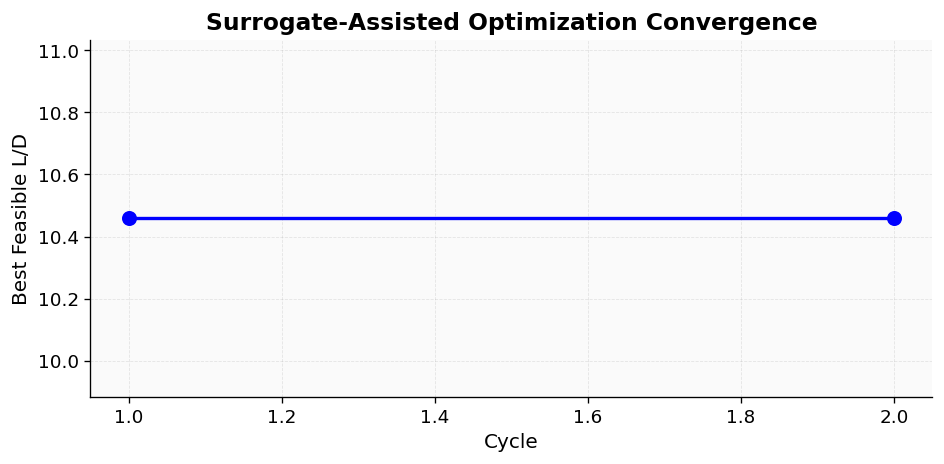

Total VLM evals: 60


In [6]:
if result.get('cycle_history'):
    cycles = result['cycle_history']
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot([c['cycle'] for c in cycles], [c['best_ld'] for c in cycles], 'bo-', lw=2, ms=8)
    ax.set_xlabel('Cycle')
    ax.set_ylabel('Best Feasible L/D')
    ax.set_title('Surrogate-Assisted Optimization Convergence')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f'Total VLM evals: {result["total_vlm_evals"]}')

## 5. Save Results

In [7]:
import json
from pathlib import Path

out = Path('../output')
out.mkdir(exist_ok=True)

if result.get('best_x') is not None:
    np.save(out / 'best_x_v2.npy', result['best_x'])
    print(f'Saved best_x_v2.npy')
    
if result.get('database'):
    result['database'].save(out / 'eval_database.json')
    
print(f'Results saved to {out}')

Saved best_x_v2.npy
Results saved to ..\output
